['date', 'open', 'high', 'low', 'close*', 'adj close**', 'volume']


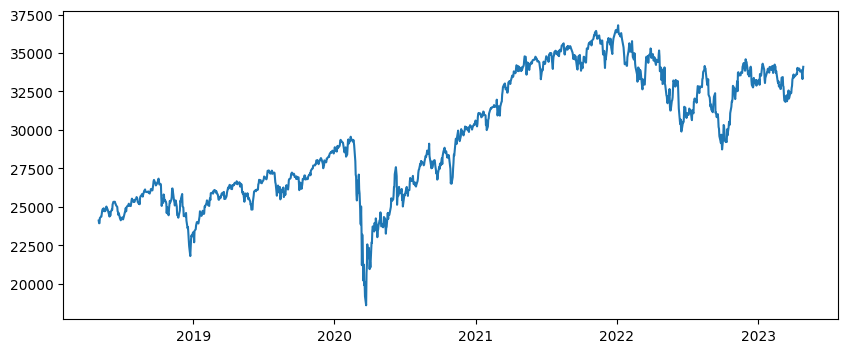

Non-stationary
Stationary


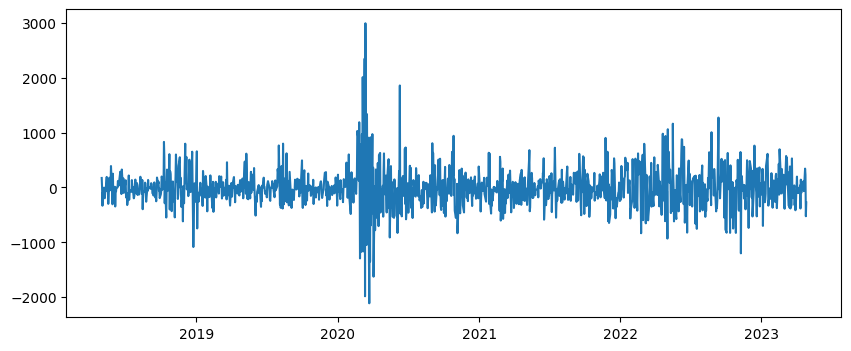

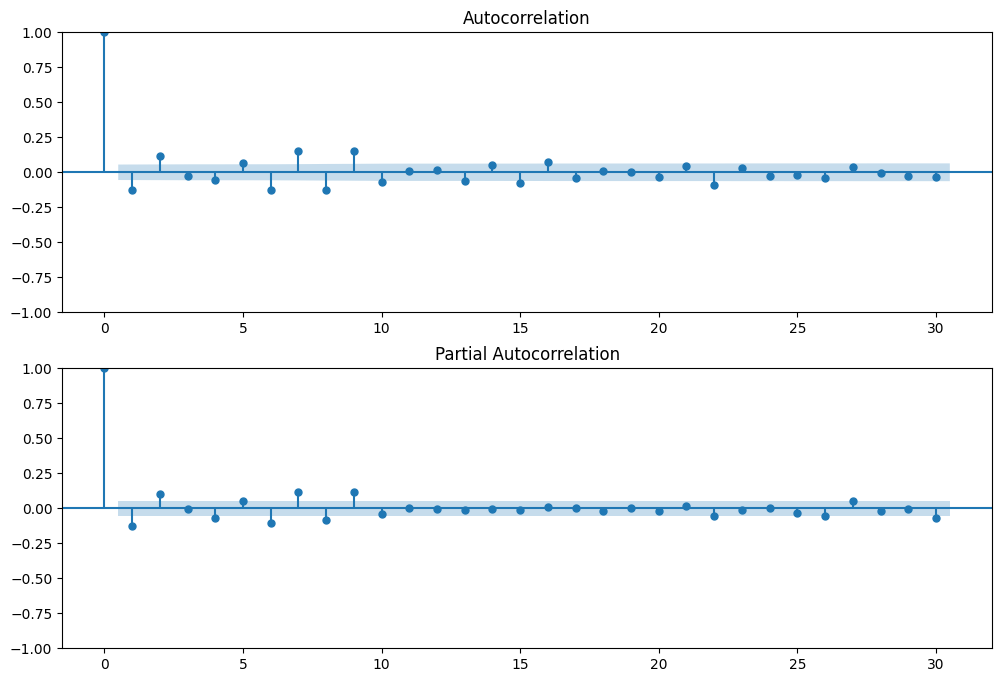

(0, 1, 0) 18364.674705949314
(1, 1, 0) 18345.548703095526
(0, 1, 1) 18348.6884100525
(1, 1, 1) 18342.00868713286


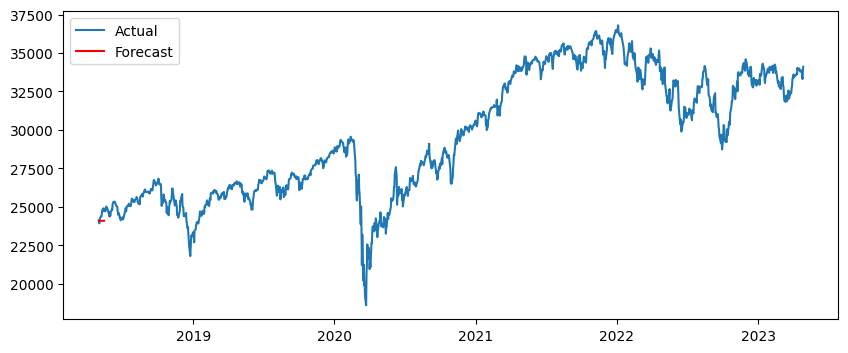

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
import warnings
warnings.filterwarnings("ignore")

df = pd.read_excel(r"D:\PythonAssigment\yahoo_data.xlsx")

df.columns = df.columns.str.strip().str.lower()
print(df.columns.tolist())

date_col = None
for col in df.columns:
    if 'date' in col:
        date_col = col
        break

df[date_col] = pd.to_datetime(df[date_col])
df.set_index(date_col, inplace=True)

price_keywords = ['close', 'adj close', 'price']
price_col = None
for col in df.columns:
    for key in price_keywords:
        if key in col:
            price_col = col
            break
    if price_col:
        break

df.rename(columns={price_col: 'price'}, inplace=True)

plt.figure(figsize=(10,4))
plt.plot(df['price'])
plt.show()

def adfuller_test(series):
    result = adfuller(series.dropna())
    if result[1] <= 0.05:
        print("Stationary")
    else:
        print("Non-stationary")

adfuller_test(df['price'])

df['price_diff'] = df['price'].diff()
adfuller_test(df['price_diff'])

plt.figure(figsize=(10,4))
plt.plot(df['price_diff'])
plt.show()

fig = plt.figure(figsize=(12,8))
ax1 = fig.add_subplot(211)
plot_acf(df['price_diff'].dropna(), lags=30, ax=ax1)
ax2 = fig.add_subplot(212)
plot_pacf(df['price_diff'].dropna(), lags=30, ax=ax2)
plt.show()

orders = [(0,1,0), (1,1,0), (0,1,1), (1,1,1)]
for order in orders:
    model = ARIMA(df['price'], order=order)
    fit = model.fit()
    print(order, fit.aic)

model = ARIMA(df['price'], order=(1,1,1))
model_fit = model.fit()

forecast_steps = 10
forecast = model_fit.forecast(steps=forecast_steps)

forecast_index = pd.date_range(
    start=df.index[-1] + pd.Timedelta(days=1),
    periods=forecast_steps,
    freq='B'
)

forecast = pd.Series(forecast.values, index=forecast_index)

plt.figure(figsize=(10,4))
plt.plot(df['price'], label='Actual')
plt.plot(forecast, label='Forecast', color='red')
plt.legend()
plt.show()
